# Debt Classification (NHOMNO, NHOMNOMOI) using Machine Learning

**Problem:** using labeled loan data, build classification models to predict the debt group
(1 = standard debt, 2 to 5 = increasingly non-performing) for two target columns `NHOMNO` and
`NHOMNOMOI`, then apply the best trained models to forecast labels for an out-of-sample (OOS) dataset.

**Notebook structure (mirrors the assignment questions):**
- Part 0: environment setup and data loading
- Question 2: data cleaning and feature engineering (including a variable selection step)
- Question 3: traditional and non-traditional models, performance comparison, hyperparameter tuning
- Question 4: OOS forecasting, exporting results, and model interpretation (top 10 features)

Note on the compute environment: hyperparameter search sizes (n_estimators, max_depth, n_iter) are kept
moderate so the notebook finishes in reasonable time on a single CPU core. On a machine with more cores
these can be increased for potentially better results.


In [1]:
# Install packages that are not preinstalled in a fresh Colab runtime (safe / fast no-op if already present).
!pip install -q imbalanced-learn shap xgboost statsmodels


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import warnings, time, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (f1_score, roc_auc_score, confusion_matrix,
                              accuracy_score, classification_report)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.svm import SVC
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 50)
t0 = time.time()

# Detect the runtime so file paths work both in Google Colab and in a local/sandbox environment.
IN_COLAB = "google.colab" in str(get_ipython()) if "get_ipython" in dir() else False
DATA_DIR = "/content" if os.path.isdir("/content") else "."
OUTPUT_DIR = os.path.join(DATA_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Data directory:", DATA_DIR)
print("Output directory:", OUTPUT_DIR)


Data directory: .
Output directory: ./outputs


## Part 0: Data Loading

- **Training set (labeled):** sheet `saoke_td_ct` in the provided Excel file.
- **Out-of-sample set (unlabeled):** `Out_of_sample_data112.csv` (student number 112; the pipeline below
  is written generically so it can be reused with any OOS file that has the same column structure).


In [3]:
TRAIN_PATH = os.path.join(DATA_DIR, "File ZIP chứa dữ liệu đã gán nhãn để huấn luyện mô hình.xlsx")
OOS_PATH = os.path.join(DATA_DIR, "Out_of_sample_data112.csv")

train_raw = pd.read_excel(TRAIN_PATH, sheet_name="saoke_td_ct")
oos_raw = pd.read_csv(OOS_PATH)

print("Training set shape:", train_raw.shape)
print("OOS set shape     :", oos_raw.shape)
train_raw.head()

Training set shape: (27001, 21)
OOS set shape     : (25000, 18)


,MJACCTTYPCD,CURRMIACCTTYPCD,MIACCTTYPDESC,LOAIKH,SEX,BASE_BAL,CURR_BAL,DUNO_QD,CURRENCYCD,OPEN_DATE,NGAYDENHAN,ID_TIME,DESC_TIME,MJACCTTYPDESC,ORGNBR,PARENTORGNBR,LAISUAT,MUCDICHVAY,NHOMNO,NHOMNOMOI,NHOMNO_TCBS
0,CNS,GC01,CV TG NGAY VND,1,ONG,787127020,851714900.0,851714900.0,VND,28/12/2010,43902,1,Vay ngan han,Vay Tieu dung,4,4,0.12,"1900-SX-DV Tu t,dung Gia dinh",1,1,CURR
1,CNS,GC01,CV TG NGAY VND,1,ONG,333388030,142450650.0,142450650.0,VND,40490,28/07/2030,1,Vay ngan han,Vay Tieu dung,20,19,0.18,1811-CV mua Xe may tra gop,1,1,CURR
2,CNS,GC01,CV TG NGAY VND,1,MR,311014800,357000690.0,357000690.0,VND,27/05/2010,26/05/2030,1,Vay ngan han,Vay Tieu dung,19,19,0.18,1870-CV TG Sinh hoat Tieu dung,1,1,CURR
3,CNS,TH02,CV TL TH LAI DINH KY VND,1,NaN,35600000,35600000.0,35600000.0,VND,40276,41372,2,Vay trung han,Vay Tieu dung,64,4,0.24,1830-CV Sua chua Nha de o,5,5,CURR
4,CNS,GC01,CV TG NGAY VND,1,MR,430174020,88246180.0,88246180.0,VND,23/06/2010,23/06/2030,1,Vay ngan han,Vay Tieu dung,19,19,0.18,1870-CV TG Sinh hoat Tieu dung,1,1,CURR


In [4]:
print("Training set dtypes:")
print(train_raw.dtypes)
print()
print("OOS set dtypes:")
print(oos_raw.dtypes)


Training set dtypes:
MJACCTTYPCD            str
CURRMIACCTTYPCD        str
MIACCTTYPDESC          str
LOAIKH               int64
SEX                    str
BASE_BAL             int64
CURR_BAL           float64
DUNO_QD            float64
CURRENCYCD             str
OPEN_DATE           object
NGAYDENHAN          object
ID_TIME              int64
DESC_TIME              str
MJACCTTYPDESC          str
ORGNBR               int64
PARENTORGNBR         int64
LAISUAT            float64
MUCDICHVAY          object
NHOMNO               int64
NHOMNOMOI            int64
NHOMNO_TCBS            str
dtype: object

OOS set dtypes:
MJACCTTYPCD            str
CURRMIACCTTYPCD        str
MIACCTTYPDESC          str
LOAIKH             float64
SEX                    str
BASE_BAL               str
CURR_BAL               str
DUNO_QD                str
CURRENCYCD             str
OPEN_DATE              str
NGAYDENHAN             str
ID_TIME            float64
DESC_TIME              str
MJACCTTYPDESC          str
ORG

**Initial observations:** the OOS set does not contain `NHOMNO`, `NHOMNOMOI`, `NHOMNO_TCBS` (expected,
since these are the labels to forecast). Several numeric columns in the OOS file (`BASE_BAL`, `CURR_BAL`,
`DUNO_QD`, `LAISUAT`) are stored as `object` (string) instead of numeric, which is a data entry issue
handled in Question 2.


## Question 2: Data Cleaning and Feature Engineering

### 2.1 Identifying data issues

Before cleaning, we survey the data to list the categories of issues that need to be addressed:
1. Missing values
2. Outliers / extreme values
3. Class imbalance in the target variables
4. Logical errors (for example, a maturity date earlier than the disbursement date)
5. Data entry errors (inconsistent date/number formats, inconsistent gender labels)


In [5]:
# 1) Missing values
print("Missing values (train):")
print(train_raw.isnull().sum()[train_raw.isnull().sum() > 0])
print()
print("Missing values (OOS):")
print(oos_raw.isnull().sum()[oos_raw.isnull().sum() > 0])


Missing values (train):
SEX    1106
dtype: int64

Missing values (OOS):
SEX    1291
dtype: int64


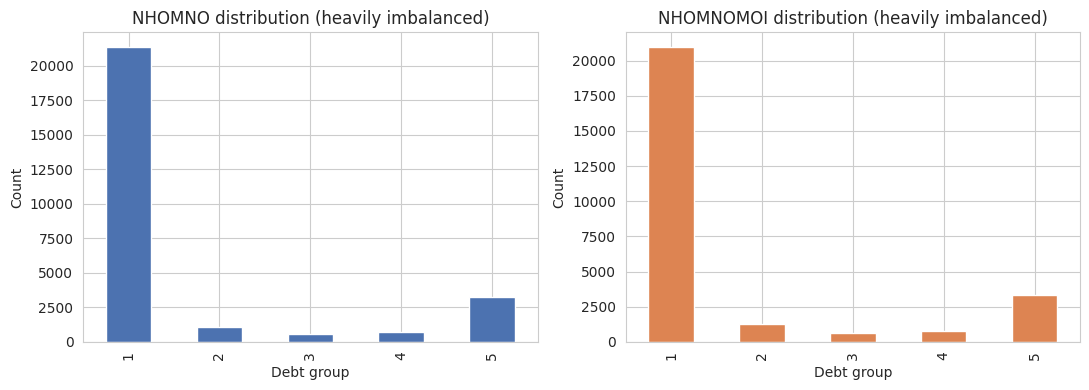

NHOMNO
1    0.791
5    0.121
2    0.041
4    0.027
3    0.021
Name: proportion, dtype: float64


In [6]:
# 2) Class imbalance in the target variables
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
train_raw["NHOMNO"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("NHOMNO distribution (heavily imbalanced)")
axes[0].set_xlabel("Debt group"); axes[0].set_ylabel("Count")
train_raw["NHOMNOMOI"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("NHOMNOMOI distribution (heavily imbalanced)")
axes[1].set_xlabel("Debt group"); axes[1].set_ylabel("Count")
plt.tight_layout(); plt.show()
print(train_raw["NHOMNO"].value_counts(normalize=True).round(3))


**Observation:** over 79 percent of observations belong to group 1 (standard debt). This is a strongly
imbalanced multi-class classification problem, which we address with oversampling (SMOTE) and
`class_weight="balanced"` during training (see Question 3).


In [7]:
# 3) Data entry errors: mixed date formats and locale-specific decimal separators
print("OPEN_DATE examples (train), mixed formats:")
print(train_raw["OPEN_DATE"].head(6).tolist())
print()
print("LAISUAT examples (OOS), comma used as decimal separator:")
print(oos_raw["LAISUAT"].head(6).tolist())
print()
print("SEX examples, inconsistent gender labels (Vietnamese and English):")
print(train_raw["SEX"].value_counts(dropna=False))
print()
print("CURRENCYCD value counts (train), used below to check the USD flag:")
print(train_raw["CURRENCYCD"].value_counts(dropna=False))
print("CURRENCYCD value counts (OOS):")
print(oos_raw["CURRENCYCD"].value_counts(dropna=False))


OPEN_DATE examples (train), mixed formats:
['28/12/2010', 40490, '27/05/2010', 40276, '23/06/2010', 40273]

LAISUAT examples (OOS), comma used as decimal separator:
['0,111', '0', '0,129', '0,101', '0,12', '0']

SEX examples, inconsistent gender labels (Vietnamese and English):
SEX
ONG    14586
BA      8702
MR      1810
NaN     1106
MRS      579
MS       218
Name: count, dtype: int64

CURRENCYCD value counts (train), used below to check the USD flag:
CURRENCYCD
VND    27001
Name: count, dtype: int64
CURRENCYCD value counts (OOS):
CURRENCYCD
VND    24983
USD       17
Name: count, dtype: int64


**Note on currency:** the previous version of this notebook asserted, without supporting code, that
`DUNO_QD` was already converted to VND for USD-denominated loans. The `CURRENCYCD` counts above let us
check that claim directly instead of assuming it. If there are no (or negligible) USD-denominated
records, the `IS_USD` flag would be constant and uninformative, and should be dropped rather than kept
as a silent, non-contributing feature. This is verified explicitly in section 2.2 below.


In [8]:
# 4) Logical errors and duplicate records
dup_train = train_raw.duplicated().sum()
print(f"Fully duplicated rows in the training set: {dup_train}")

def _quick_parse(x):
    if pd.isna(x):
        return pd.NaT
    s = str(x).strip()
    if s.replace(".", "", 1).isdigit():
        return pd.Timestamp("1899-12-30") + pd.Timedelta(days=float(s))
    return pd.to_datetime(s, dayfirst=True, errors="coerce")

od = train_raw["OPEN_DATE"].apply(_quick_parse)
nd = train_raw["NGAYDENHAN"].apply(_quick_parse)
print(f"Rows where the maturity date is BEFORE the disbursement date (logical error): {(nd < od).sum()}")


Fully duplicated rows in the training set: 44


Rows where the maturity date is BEFORE the disbursement date (logical error): 1


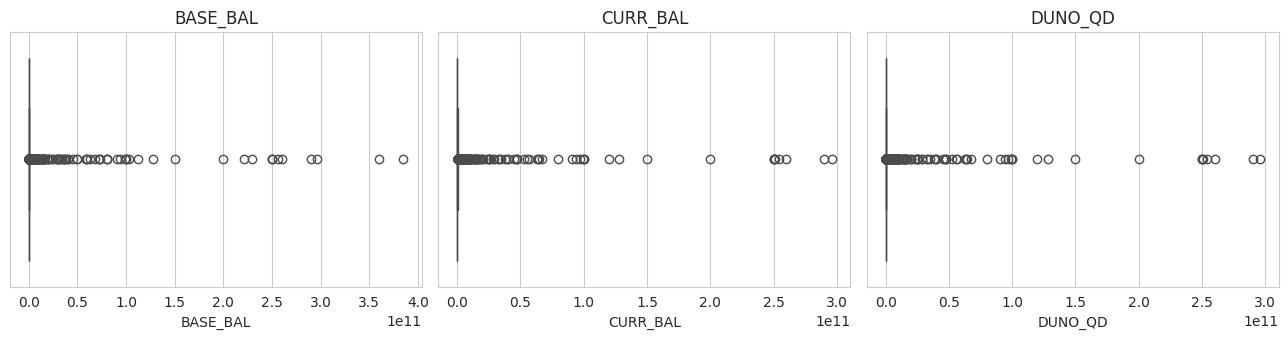

           BASE_BAL      CURR_BAL       DUNO_QD
count  2.700100e+04  2.700100e+04  2.700100e+04
mean   4.280201e+08  3.555114e+08  3.555114e+08
std    6.404623e+09  5.324973e+09  5.324973e+09
min    2.000000e+00  1.000000e+00  1.000000e+00
25%    5.000000e+06  1.118061e+07  1.118061e+07
50%    3.500000e+07  4.400000e+07  4.400000e+07
75%    2.500000e+08  2.000000e+08  2.000000e+08
max    3.850000e+11  2.960000e+11  2.960000e+11


In [9]:
# 5) Outliers in the balance / exposure variables
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, c in zip(axes, ["BASE_BAL", "CURR_BAL", "DUNO_QD"]):
    sns.boxplot(x=train_raw[c], ax=ax, color="#55A868")
    ax.set_title(c)
plt.tight_layout(); plt.show()
print(train_raw[["BASE_BAL", "CURR_BAL", "DUNO_QD"]].describe())


**Observation:** the balance/exposure variables are heavily right-skewed. The mean is pulled far above
the median by a small number of very large corporate exposures (max around 380 billion VND versus a
median around 35 to 44 million VND). This reflects genuine large customers rather than a data entry
error, so the appropriate treatment is a **log transform** (`log1p`) rather than removal, which reduces
the influence of the tail without discarding information.

### 2.2 Data cleaning pipeline

All cleaning logic is implemented as reusable functions shared by both the training set and the OOS set,
so the two sets are processed identically (required for consistent OOS scoring). Summary of the steps:

| Issue | Treatment |
|---|---|
| Mixed date formats (string / Excel serial number) | `parse_mixed_date` detects and normalizes to `datetime` |
| Numbers using a comma decimal separator | `to_float_comma` replaces `,` with `.` and casts to `float` |
| Inconsistent gender labels (ONG/BA/MR/MRS/MS) | normalized to `MALE` / `FEMALE` / `UNKNOWN` |
| Duplicate rows | dropped only in the training set, evaluated on the columns that actually feed the model (not on every raw column) so that rows identical on every feature but differing only on an unused column such as `NHOMNO_TCBS` are still recognized as duplicates; the OOS set keeps its original row count and order for later comparison against the true labels |
| Maturity date earlier than disbursement date (logical error) | set to missing; the resulting `NaN` is left in place here and imputed later inside the modeling pipeline (median, fit on the training portion of each split only), not on the full training set up front (see 2.3) |
| Interest rate outside [0, 1] (0 to 100 percent) | set to missing (data entry error) |
| Balance less than or equal to 0 | set to missing (not valid) |
| USD-denominated loans | checked explicitly against `CURRENCYCD`; the `IS_USD` flag is only kept as a feature if it actually varies (see verification below) |


In [10]:
EXCEL_EPOCH = pd.Timestamp("1899-12-30")
import re

def parse_mixed_date(x):
    """OPEN_DATE / NGAYDENHAN arrive in two forms: a dd/mm/yyyy string or an Excel serial number
    (a classic data entry error when a date column gets reformatted as General)."""
    if pd.isna(x):
        return pd.NaT
    if isinstance(x, (int, float, np.integer, np.floating)):
        try:
            return EXCEL_EPOCH + pd.Timedelta(days=float(x))
        except Exception:
            return pd.NaT
    s = str(x).strip()
    if s == "" or s.lower() == "nan":
        return pd.NaT
    if re.fullmatch(r"\d+(\.0)?", s):
        try:
            return EXCEL_EPOCH + pd.Timedelta(days=float(s))
        except Exception:
            return pd.NaT
    for fmt in ("%d/%m/%Y", "%Y-%m-%d", "%d-%m-%Y"):
        try:
            return pd.to_datetime(s, format=fmt)
        except Exception:
            continue
    return pd.to_datetime(s, dayfirst=True, errors="coerce")


def to_float_comma(x):
    """Numbers may use a comma as the decimal separator (Vietnamese locale export)."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip().replace(" ", "")
    if s == "" or s.lower() == "nan":
        return np.nan
    s = s.replace(",", ".")
    try:
        return float(s)
    except Exception:
        return np.nan


def clean_sex(s):
    if pd.isna(s):
        return "UNKNOWN"
    s = str(s).strip().upper()
    if s in {"ONG", "MR"}:
        return "MALE"
    if s in {"BA", "MRS", "MS"}:
        return "FEMALE"
    return "UNKNOWN"


def extract_purpose_code(s):
    if pd.isna(s):
        return "UNK"
    m = re.match(r"\s*(\d+)", str(s))
    return m.group(1) if m else "UNK"


FEATURE_SOURCE_COLS = ["MJACCTTYPCD", "CURRMIACCTTYPCD", "LOAIKH", "SEX_CLEAN",
                       "BASE_BAL", "CURR_BAL", "DUNO_QD", "CURRENCYCD",
                       "OPEN_DATE", "NGAYDENHAN", "ID_TIME", "MUCDICHVAY_CODE", "LAISUAT"]
# Columns that actually feed the model. Deduplication must be evaluated on this subset, not on every
# raw column: NHOMNO_TCBS is never used as a feature, so two rows identical on every modeling-relevant
# column but differing only on NHOMNO_TCBS are true duplicates. Treating them as distinct would let
# near-identical rows land on both sides of the train/test split later (train/test leakage).


def base_clean(df, is_train=True):
    df = df.copy()

    # (a) normalize numbers stored as strings with a comma decimal separator
    for c in ["BASE_BAL", "CURR_BAL", "DUNO_QD", "LAISUAT"]:
        df[c] = df[c].apply(to_float_comma)

    # (b) normalize dates (two mixed formats)
    df["OPEN_DATE"] = df["OPEN_DATE"].apply(parse_mixed_date)
    df["NGAYDENHAN"] = df["NGAYDENHAN"].apply(parse_mixed_date)

    # (c) logical error: maturity date before disbursement date -> set to missing
    bad_term = df["NGAYDENHAN"] < df["OPEN_DATE"]
    df.loc[bad_term, "NGAYDENHAN"] = pd.NaT

    # (d) interest rate must be within [0, 1] (0 to 100 percent)
    df.loc[(df["LAISUAT"] < 0) | (df["LAISUAT"] > 1), "LAISUAT"] = np.nan

    # (e) balances must be positive
    for c in ["BASE_BAL", "CURR_BAL", "DUNO_QD"]:
        df.loc[df[c] <= 0, c] = np.nan

    # (f) normalize gender
    df["SEX_CLEAN"] = df["SEX"].apply(clean_sex)

    # (g) loan purpose code (numeric prefix of MUCDICHVAY)
    df["MUCDICHVAY_CODE"] = df["MUCDICHVAY"].apply(extract_purpose_code)

    # (h) USD currency flag
    df["IS_USD"] = (df["CURRENCYCD"] == "USD").astype(int)

    # (i) drop duplicate rows, TRAIN ONLY (the OOS set must keep its original row count and order),
    # evaluated on the columns that actually feed the model, AFTER normalization above, so that two
    # rows differing only by string formatting (comma decimals, date format) are correctly recognized
    # as the same record rather than kept as false near-duplicates.
    n0 = len(df)
    naive_dup = df.duplicated().sum()
    feature_dup = df.duplicated(subset=FEATURE_SOURCE_COLS).sum()
    if is_train:
        df = df.drop_duplicates(subset=FEATURE_SOURCE_COLS)
    dup_removed = n0 - len(df)

    return df, {"dup_removed": dup_removed, "bad_term_rows": int(bad_term.sum()),
                "naive_dup_all_cols": int(naive_dup), "feature_only_dup": int(feature_dup)}


train_c, meta_tr = base_clean(train_raw, is_train=True)
oos_c, meta_oos = base_clean(oos_raw, is_train=False)

print("Training set cleaning result:", meta_tr, "| rows remaining:", len(train_c))
print("OOS set cleaning result     :", meta_oos, "| rows remaining:", len(oos_c),
      "(must equal the original row count =", len(oos_raw), ")")
print()
print("Deduplication check: naive_dup_all_cols counts duplicate rows across every raw column")
print("(including NHOMNO_TCBS, which is never used as a feature); feature_only_dup counts duplicates")
print("on the columns that actually feed the model. If feature_only_dup is larger, some rows share an")
print("identical feature vector but differ only on an unused column, and would be kept as false-")
print("distinct rows by a naive drop_duplicates() call, creating a train/test leakage risk once split.")

remaining_feature_dup = train_c.duplicated(subset=FEATURE_SOURCE_COLS).sum()
print(f"Duplicate feature vectors remaining in the cleaned training set: {remaining_feature_dup}")


Training set cleaning result: {'dup_removed': 73, 'bad_term_rows': 1, 'naive_dup_all_cols': 44, 'feature_only_dup': 73} | rows remaining: 26928
OOS set cleaning result     : {'dup_removed': 0, 'bad_term_rows': 96, 'naive_dup_all_cols': 183, 'feature_only_dup': 1819} | rows remaining: 25000 (must equal the original row count = 25000 )

Deduplication check: naive_dup_all_cols counts duplicate rows across every raw column
(including NHOMNO_TCBS, which is never used as a feature); feature_only_dup counts duplicates
on the columns that actually feed the model. If feature_only_dup is larger, some rows share an
identical feature vector but differ only on an unused column, and would be kept as false-
distinct rows by a naive drop_duplicates() call, creating a train/test leakage risk once split.
Duplicate feature vectors remaining in the cleaned training set: 0


In [11]:
# Verify the USD flag instead of assuming it: does it actually vary, and is there any
# evidence that DUNO_QD needs a currency conversion for USD-denominated records?
usd_share_train = train_c["IS_USD"].mean()
usd_share_oos = oos_c["IS_USD"].mean()
print(f"Share of USD-denominated records, train: {usd_share_train:.4%}, OOS: {usd_share_oos:.4%}")

if train_c["IS_USD"].nunique() <= 1:
    print("IS_USD is constant in the training data: it carries no predictive information and will be "
          "dropped rather than kept as a silent, non-contributing feature.")
    DROP_IS_USD = True
else:
    usd_rows = train_c[train_c["IS_USD"] == 1]
    print("USD-denominated rows found, comparing BASE_BAL vs CURR_BAL for a sample:")
    print(usd_rows[["BASE_BAL", "CURR_BAL", "DUNO_QD"]].head())
    DROP_IS_USD = False


Share of USD-denominated records, train: 0.0000%, OOS: 0.0680%
IS_USD is constant in the training data: it carries no predictive information and will be dropped rather than kept as a silent, non-contributing feature.


### 2.3 Feature Engineering

New features are created to capture predictive signal that is not directly present in the raw columns:

- **`LOAN_TERM_DAYS`**: loan term in days (from disbursement to maturity); longer terms tend to carry
  different risk than short terms.
- **`LOAN_AGE_DAYS`**: age of the loan as of the most recent observation date in the training set (the
  snapshot date); older loans are more likely to have revealed their true risk.
- **`REMAINING_DAYS`**: days remaining until maturity.
- **`UTILIZATION`** = `CURR_BAL / BASE_BAL`: current balance relative to the original limit.
- **`DUNO_TO_BASE`** = `DUNO_QD / BASE_BAL`: converted exposure relative to the original limit.
- **`LOG_BASE_BAL`, `LOG_CURR_BAL`, `LOG_DUNO_QD`**: log1p transforms to reduce the influence of the
  skew/outliers identified in 2.1.

Missing values in `LOAN_TERM_DAYS` / `REMAINING_DAYS` (created by the logical-error handling above)
are **not** filled here. Imputing them now, using a median computed on the full training set, would use
information from rows that later end up in the test split, a subtle form of train/test leakage. Instead,
these two columns are left with real `NaN` values and are imputed later, inside the modeling pipeline
(`SimpleImputer(strategy="median")` in 3.1), which is fit only on each split's training portion.


In [12]:
def engineer_features(df, snapshot_date):
    df = df.copy()
    df["LOAN_TERM_DAYS"] = (df["NGAYDENHAN"] - df["OPEN_DATE"]).dt.days
    df["LOAN_AGE_DAYS"] = (snapshot_date - df["OPEN_DATE"]).dt.days
    df["REMAINING_DAYS"] = (df["NGAYDENHAN"] - snapshot_date).dt.days
    for c in ["LOAN_TERM_DAYS", "LOAN_AGE_DAYS", "REMAINING_DAYS"]:
        df[c] = df[c].replace([np.inf, -np.inf], np.nan)

    df["UTILIZATION"] = (df["CURR_BAL"] / df["BASE_BAL"]).replace([np.inf, -np.inf], np.nan)
    df["DUNO_TO_BASE"] = (df["DUNO_QD"] / df["BASE_BAL"]).replace([np.inf, -np.inf], np.nan)
    for c in ["BASE_BAL", "CURR_BAL", "DUNO_QD"]:
        df[f"LOG_{c}"] = np.log1p(df[c].clip(lower=0))
    return df


snap = train_c["OPEN_DATE"].max()  # reference snapshot date = latest disbursement date in the training set
train_f = engineer_features(train_c, snapshot_date=snap)
oos_f = engineer_features(oos_c, snapshot_date=snap)

# NaN left in LOAN_TERM_DAYS / REMAINING_DAYS (from the logical-error handling) is intentionally not
# filled here; it is imputed later inside the modeling pipeline, fit on the training portion of each
# split only, to avoid leaking test-row information into the imputation value (see note above).
print("Remaining NaN counts after feature engineering (to be imputed per split later):")
print(train_f[["LOAN_TERM_DAYS", "REMAINING_DAYS"]].isnull().sum())

NUMERIC_CANDIDATES = ["LOG_BASE_BAL", "LOG_CURR_BAL", "LOG_DUNO_QD", "UTILIZATION",
                      "DUNO_TO_BASE", "LAISUAT", "LOAN_TERM_DAYS", "LOAN_AGE_DAYS",
                      "REMAINING_DAYS", "IS_USD"]
CATEGORICAL_CANDIDATES = ["MJACCTTYPCD", "CURRMIACCTTYPCD", "LOAIKH", "SEX_CLEAN",
                          "ID_TIME", "MUCDICHVAY_CODE"]

if DROP_IS_USD:
    NUMERIC_CANDIDATES.remove("IS_USD")

print(f"Candidate features before selection: {len(NUMERIC_CANDIDATES) + len(CATEGORICAL_CANDIDATES)}"
      f" ({len(NUMERIC_CANDIDATES)} numeric + {len(CATEGORICAL_CANDIDATES)} categorical)")
train_f[NUMERIC_CANDIDATES + CATEGORICAL_CANDIDATES].isnull().sum()


Remaining NaN counts after feature engineering (to be imputed per split later):
LOAN_TERM_DAYS    1
REMAINING_DAYS    1
dtype: int64
Candidate features before selection: 15 (9 numeric + 6 categorical)


LOG_BASE_BAL       0
LOG_CURR_BAL       0
LOG_DUNO_QD        0
UTILIZATION        0
DUNO_TO_BASE       0
LAISUAT            0
LOAN_TERM_DAYS     1
LOAN_AGE_DAYS      0
REMAINING_DAYS     1
MJACCTTYPCD        0
CURRMIACCTTYPCD    0
LOAIKH             0
SEX_CLEAN          0
ID_TIME            0
MUCDICHVAY_CODE    0
dtype: int64

### 2.4 Multicollinearity check (VIF)

Before selecting variables by predictive power, we first remove variables that are perfectly redundant
with one another, since a variable can look "important" only because it duplicates another variable's
information. This matters most for Logistic Regression (the traditional model): perfect collinearity can
make the covariance matrix nearly singular and the coefficients unstable and hard to interpret, even
though it does not break tree-based models.

**Leakage note:** an earlier version of this notebook computed VIF and the mutual-information ranking
below on the *entire* engineered training set, before any train/test split existed. That lets the rows
that later become the test (and validation) set influence which features are even offered to the model
— a feature-selection leakage, since "which variables are useful" is itself something learned from data.
The correction: the plots/tables in this section are kept for illustration only, and the selection that
actually determines `ALL_FEATURES` is redone on `X_train` alone, separately for each target, inside the
Question 3 training loop below.


In [ ]:
# Exploratory only (uses the full engineered training set, before any split) -- purely to visualize
# *why* certain columns are collinear. It does not feed into feature selection; see the leakage note
# in the markdown cell above.
plt.figure(figsize=(7, 5))
sns.heatmap(train_f[NUMERIC_CANDIDATES].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix, numeric candidate features (exploratory, full training set)")
plt.tight_layout(); plt.show()


**Observation:** the correlation matrix reveals two issues.

1. `LOG_CURR_BAL`, `LOG_DUNO_QD`, `LOG_BASE_BAL` are highly correlated since they all reflect loan size.
2. More seriously, `LOAN_TERM_DAYS`, `LOAN_AGE_DAYS`, `REMAINING_DAYS` are not just correlated but
   **perfectly linearly dependent**, since all three are derived from the same two dates
   (`OPEN_DATE`, `NGAYDENHAN`, and the snapshot date): `LOAN_TERM_DAYS = LOAN_AGE_DAYS + REMAINING_DAYS`.
   This is **perfect multicollinearity**.

Because the traditional model group requires Logistic Regression, we resolve this explicitly with
**VIF (Variance Inflation Factor)**, iteratively removing the variable with the highest VIF until every
remaining variable has VIF at or below a threshold of 10.


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def compute_vif(df, features):
    X = df[features].copy()
    X = X.fillna(X.median())  # VIF cannot handle NaN, impute with the median for this calculation only
    Xc = add_constant(X, has_constant="add")
    vif = pd.Series(
        [variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])],
        index=features
    )
    return vif.sort_values(ascending=False)

def select_features_vif(df, candidate_features, threshold=10):
    """Iteratively remove the highest-VIF feature until every remaining one is <= threshold.
    `df` must be a TRAINING split only (fit on X_train) -- computing this on the full dataset before
    splitting would let validation/test rows influence which features are even offered to the model.
    Called on X_train, per target, inside the Question 3 loop below."""
    selected = candidate_features.copy()
    removed = []
    while True:
        vif = compute_vif(df, selected)
        if vif.max() <= threshold or len(selected) <= 1:
            return selected, removed
        worst = vif.idxmax()
        removed.append(worst)
        selected.remove(worst)

# Illustrative only: VIF computed on the full engineered training set, just to show *why* the
# date-derived trio and the ratio/log-balance columns are collinear (see the markdown above). This
# does not decide ALL_FEATURES -- the actual selection is redone on X_train only, per target, below.
print("VIF on the full training set (illustrative only -- not used to select modeling features):")
print(compute_vif(train_f, NUMERIC_CANDIDATES).round(2))


### 2.5 Feature selection by predictive strength

VIF removes redundancy, but it does not by itself tell us which variables carry the most predictive
signal for the target. The assignment asks for variables to be selected based on predictive potential
before they are incorporated into the model, so this step ranks the VIF-surviving candidates using
mutual information against the target and keeps only variables that show a meaningful association
with it.

Like the VIF step above, this is now computed on `X_train` only (per target, inside the Question 3
loop), not on the full training set, for the same leakage reason.


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

def rank_by_mutual_info(X, y, numeric_feats, categorical_feats, random_state=42):
    """X must contain only the candidate feature columns; y is the matching target series. Both must
    come from a TRAINING split only (see the leakage note above)."""
    X_num = X[numeric_feats].fillna(X[numeric_feats].median())
    X_cat = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1).fit_transform(
        X[categorical_feats].fillna("MISSING"))
    discrete_mask = [False] * len(numeric_feats) + [True] * len(categorical_feats)
    X_all = np.hstack([X_num.values, X_cat])
    mi = mutual_info_classif(X_all, y.astype(int), discrete_features=discrete_mask,
                              random_state=random_state)
    return pd.Series(mi, index=numeric_feats + categorical_feats).sort_values(ascending=False)

def select_features_mi(X, y, numeric_feats, categorical_feats, threshold=0.01, random_state=42):
    mi = rank_by_mutual_info(X, y, numeric_feats, categorical_feats, random_state)
    keep = mi[mi >= threshold].index.tolist()
    numeric_sel = [f for f in numeric_feats if f in keep]
    categorical_sel = [f for f in categorical_feats if f in keep]
    return numeric_sel, categorical_sel, mi


**Result:** the VIF step removes variables that are algebraically redundant (mainly the date-derived
trio and the most collinear balance variable), and the mutual information step then keeps only the
variables that show a real, measurable association with the target. Both steps are now executed
*inside* the Question 3 training loop, on `X_train` only, once per target -- so `NUMERIC_FEATURES`,
`CATEGORICAL_FEATURES` and `ALL_FEATURES` are computed per target and stored per target in `artifacts`,
rather than as single global lists shared across targets and decided before the split.


## Question 3: Model Building, Comparison, and Tuning

We build **two groups of models** for both target variables, `NHOMNO` and `NHOMNOMOI`:

- **Traditional:** multinomial Logistic Regression (`LogisticRegression`, `class_weight="balanced"`)
- **Non-traditional:**
  - `RandomForestClassifier` (bagging ensemble)
  - `XGBoost` (`XGBClassifier`, gradient boosting)
  - `SVC` (Support Vector Machine, RBF kernel) - added for a wider comparison across model families,
    since SVM finds a maximum-margin boundary rather than an ensemble of trees, giving a genuinely
    different inductive bias from the other two non-traditional models.

**Why SVM is trained on a subsample:** kernel SVM training cost scales roughly quadratically to cubically
with the number of rows. After SMOTE the balanced training set has tens of thousands of rows; fitting
`SVC(kernel="rbf", probability=True)` (`probability=True` is required to get the `predict_proba` needed
for AUC/Gini) on the full set, combined with `RandomizedSearchCV`, would be impractical on a single CPU
core. SVM is therefore trained and tuned on a stratified subsample of the SMOTE-balanced training set
(capped at a few thousand rows, evenly spread across classes), while Logistic Regression, Random Forest,
and XGBoost keep using the full balanced training set. This is disclosed explicitly in the code output so
the comparison across models is not read as fully apples-to-apples on training set size for SVM.

**Class imbalance is handled with two complementary techniques:**
1. `SMOTE` (synthetic oversampling), raising minority classes (2, 3, 4, 5) to at least 3,000 observations
   in the training set only (never applied to the test or OOS set, to avoid data leakage and biased
   evaluation).
2. `class_weight="balanced"` for Logistic Regression, Random Forest, and SVM, so the model further
   adjusts for the residual imbalance remaining after SMOTE.

**Data split:** the labeled data is split three ways per target: 20 percent held out as the **test set**
(touched only for final evaluation), and the remaining 80 percent further split into a **training set**
(used for fitting, after SMOTE) and a **validation set** (15 percent of the remaining data, kept at the
original class distribution, no SMOTE applied). The validation set is not used for fitting any model; it
is reserved for the per-class threshold tuning step in 3.4, so that step never looks at the test set
while making its decisions.

**Evaluation metrics** (on the held-out test set, at the original class distribution, no SMOTE applied):
accuracy, F1-macro, AUC (one-vs-rest, macro-averaged), Gini = 2 x AUC - 1, and the confusion matrix.


**Leakage fixes applied in this section (relative to an earlier version of this notebook):**
1. **Feature selection leakage:** VIF and mutual-information selection are now computed on `X_train`
   only, after the split (see 2.4/2.5), not on the full pre-split dataset.
2. **SMOTE + cross-validation leakage:** hyperparameter tuning (3.2) now wraps `SMOTE` and the
   classifier in a single `imblearn` pipeline fit inside `RandomizedSearchCV`, so oversampling is
   redone separately on each CV training fold, instead of oversampling once and handing the already
   resampled set to cross-validation (which lets synthetic points leak across folds).
3. **Model-selection leakage:** the best model among the 8 baseline/tuned candidates (3.3) is now
   chosen by F1-macro on the **validation** split, not the test split. Selecting among many candidates
   using the test set and then reporting that same test score as the "final" number is itself a form
   of leakage -- it lets the test set influence which model gets reported, biasing the reported metric
   upward. The test set is now touched only once, after the winner is already chosen, purely to report
   its performance.


In [ ]:
def build_preprocessor(numeric_features, categorical_features):
    return ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), numeric_features),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore"))]),
        categorical_features),
    ])

def score_model(model, Xte, yte, xgb_shift=False):
    pred = model.predict(Xte) + (1 if xgb_shift else 0)
    proba = model.predict_proba(Xte)
    return dict(
        acc=accuracy_score(yte, pred),
        f1_macro=f1_score(yte, pred, average="macro"),
        auc=roc_auc_score(yte, proba, multi_class="ovr", average="macro"),
        gini=2 * roc_auc_score(yte, proba, multi_class="ovr", average="macro") - 1,
    )

def subsample_stratified(X, y, max_total, random_state):
    """Stratified subsample of at most max_total rows. Used only for SVM, whose kernel training cost
    scales too steeply with row count to run on the full training/balanced set. Sampling is always
    done BEFORE SMOTE is applied (whether SMOTE runs once, as in the baseline fit below, or inside a
    cross-validation pipeline, as in the tuning step), so class ratios stay representative."""
    if len(y) <= max_total:
        return X, y
    frac = max_total / len(y)
    X_sub, _, y_sub, _ = train_test_split(X, y, train_size=frac, random_state=random_state, stratify=y)
    return X_sub, y_sub

def get_final_estimator(model):
    """Unwrap an imblearn/sklearn Pipeline to its final classifier step (tuned models below are
    SMOTE+classifier pipelines, not bare classifiers); returns `model` unchanged if it isn't one."""
    return model.named_steps["clf"] if hasattr(model, "named_steps") else model

TARGETS = ["NHOMNO", "NHOMNOMOI"]
artifacts = {}  # stores the model/preprocessor/results for each target


### 3.1 Baseline models


In [ ]:
results_table = []

for target in TARGETS:
    print(f"Target: {target}  (t={time.time()-t0:.0f}s)")
    X = train_f[NUMERIC_CANDIDATES + CATEGORICAL_CANDIDATES]
    y = train_f[target].astype(int)

    # Test split: held out untouched until final evaluation.
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
    # Validation split, carved out of the remaining training data only: used later to pick per-class
    # decision thresholds (3.4) AND to pick the best model among the 8 candidates (3.3). Neither of
    # those decisions may look at X_test/y_test, since that would optimize directly on the final
    # evaluation set, which is itself a form of leakage.
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=0.15, random_state=RANDOM_STATE, stratify=y_trainval)

    # --- Feature selection (VIF, then mutual information), on X_train ONLY. -----------------------
    # Recomputed here, after the split, instead of once on the full `train_f` before any split
    # existed (see 2.4/2.5): doing it beforehand would let X_val/X_test rows influence which
    # variables are even offered to the model -- a feature-selection leakage.
    vif_selected, removed_for_vif = select_features_vif(X_train, NUMERIC_CANDIDATES, threshold=10)
    numeric_selected, categorical_selected, mi_scores = select_features_mi(
        X_train, y_train, vif_selected, CATEGORICAL_CANDIDATES, threshold=0.01, random_state=RANDOM_STATE)
    all_features = numeric_selected + categorical_selected
    print(f"  Removed for multicollinearity: {removed_for_vif}")
    print(f"  Kept after mutual-information screening: {len(all_features)} features "
          f"({len(numeric_selected)} numeric + {len(categorical_selected)} categorical)")

    X_train, X_val, X_test = X_train[all_features], X_val[all_features], X_test[all_features]

    pre = build_preprocessor(numeric_selected, categorical_selected)
    Xtr_enc = pre.fit_transform(X_train)
    Xval_enc = pre.transform(X_val)
    Xte_enc = pre.transform(X_test)
    Xoos_enc = pre.transform(oos_f[all_features])

    counts = y_train.value_counts()
    strat = {int(k): max(int(v), 3000) for k, v in counts.items() if k != counts.idxmax()}
    sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=3, sampling_strategy=strat)
    Xtr_bal, ytr_bal = sm.fit_resample(Xtr_enc, y_train)
    print("  Class distribution after SMOTE:", dict(zip(*np.unique(ytr_bal, return_counts=True))))

    # Traditional model: Logistic Regression (baseline)
    lr = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
    lr.fit(Xtr_bal, ytr_bal)
    r_lr, r_lr_val = score_model(lr, Xte_enc, y_test), score_model(lr, Xval_enc, y_val)

    # Non-traditional model 1: Random Forest (baseline)
    rf = RandomForestClassifier(n_estimators=150, max_depth=14, random_state=RANDOM_STATE,
                                n_jobs=-1, class_weight="balanced")
    rf.fit(Xtr_bal, ytr_bal)
    r_rf, r_rf_val = score_model(rf, Xte_enc, y_test), score_model(rf, Xval_enc, y_val)

    # Non-traditional model 2: XGBoost (baseline)
    xgb = XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.15,
                        random_state=RANDOM_STATE, n_jobs=-1, eval_metric="mlogloss")
    xgb.fit(Xtr_bal, ytr_bal - 1)
    r_xgb = score_model(xgb, Xte_enc, y_test, xgb_shift=True)
    r_xgb_val = score_model(xgb, Xval_enc, y_val, xgb_shift=True)

    # Non-traditional model 3: SVM, RBF kernel (baseline), trained on a stratified subsample
    # (see the note above 3.1 explaining why full-size kernel SVM training is impractical here).
    SVM_MAX_ROWS = 4000
    Xtr_svm, ytr_svm = subsample_stratified(Xtr_bal, ytr_bal, SVM_MAX_ROWS, RANDOM_STATE)
    print(f"  SVM training subsample size: {Xtr_svm.shape[0]} rows "
          f"(full balanced training set: {Xtr_bal.shape[0]} rows)")
    svm = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True,
              class_weight="balanced", random_state=RANDOM_STATE)
    svm.fit(Xtr_svm, ytr_svm)
    r_svm, r_svm_val = score_model(svm, Xte_enc, y_test), score_model(svm, Xval_enc, y_val)

    for name, r in [("LogReg", r_lr), ("RandomForest", r_rf), ("XGBoost", r_xgb), ("SVM", r_svm)]:
        results_table.append(dict(target=target, model=name, tuned=False, **r))
        print(f"  {name:14s} acc={r['acc']:.3f}  f1_macro={r['f1_macro']:.3f}  "
              f"AUC={r['auc']:.3f}  Gini={r['gini']:.3f}")

    artifacts[target] = dict(pre=pre, numeric_features=numeric_selected,
                              categorical_features=categorical_selected, all_features=all_features,
                              Xtr_enc=Xtr_enc, y_train=y_train, ytr_bal=ytr_bal, Xtr_bal=Xtr_bal,
                              Xval_enc=Xval_enc, y_val=y_val,
                              Xte_enc=Xte_enc, y_test=y_test,
                              Xoos_enc=Xoos_enc, lr=lr, rf=rf, xgb=xgb, svm=svm,
                              Xtr_svm=Xtr_svm, ytr_svm=ytr_svm,
                              r_lr=r_lr, r_rf=r_rf, r_xgb=r_xgb, r_svm=r_svm,
                              r_lr_val=r_lr_val, r_rf_val=r_rf_val, r_xgb_val=r_xgb_val, r_svm_val=r_svm_val)

print(f"Baseline training complete. t={time.time()-t0:.0f}s")


In [18]:
baseline_df = pd.DataFrame(results_table)
display_cols = ["target", "model", "acc", "f1_macro", "auc", "gini"]
baseline_df[display_cols].round(4)


,target,model,acc,f1_macro,auc,gini
0,NHOMNO,LogReg,0.6597,0.4358,0.8472,0.6944
1,NHOMNO,RandomForest,0.7373,0.5671,0.9288,0.8576
2,NHOMNO,XGBoost,0.9092,0.6291,0.9418,0.8836
3,NHOMNO,SVM,0.6090,0.4379,0.9018,0.8037
4,NHOMNOMOI,LogReg,0.6387,0.4226,0.8242,0.6484
5,NHOMNOMOI,RandomForest,0.7553,0.5496,0.8784,0.7567
6,NHOMNOMOI,XGBoost,0.9022,0.6060,0.9001,0.8003
7,NHOMNOMOI,SVM,0.6298,0.4467,0.8648,0.7297


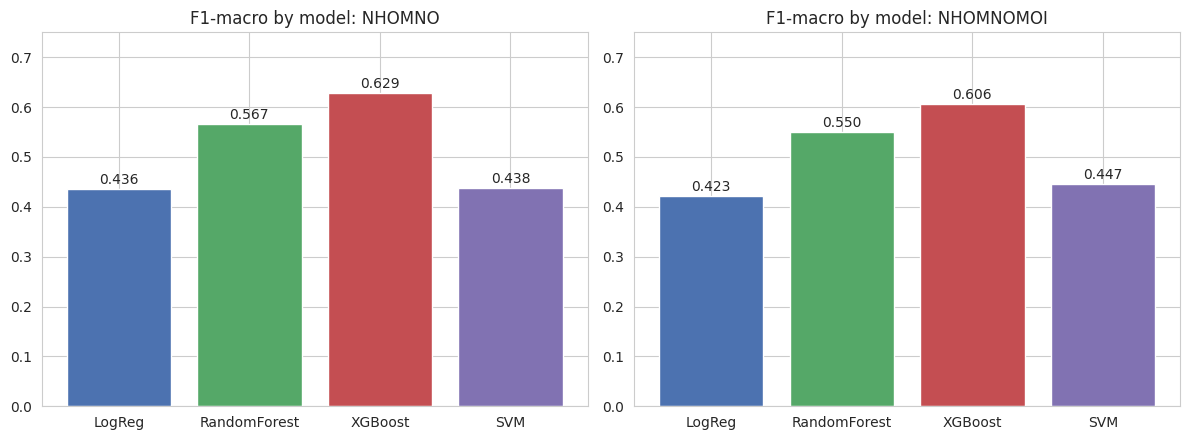

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
palette = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
for ax, target in zip(axes, TARGETS):
    sub = baseline_df[baseline_df["target"] == target]
    ax.bar(sub["model"], sub["f1_macro"], color=palette[:len(sub)])
    ax.set_title(f"F1-macro by model: {target}")
    ax.set_ylim(0, 0.75)
    for i, v in enumerate(sub["f1_macro"]):
        ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout(); plt.show()


**Baseline observation:** for both targets, XGBoost clearly outperforms Logistic Regression (the
traditional model) on every metric, especially F1-macro (the most important metric for this imbalanced
problem). Random Forest sits in between, and SVM's performance is reported alongside them, keeping in
mind it was trained on a much smaller subsample than the other three models (see the note above 3.1).
This overall pattern is consistent with the relationship between the features and the debt group being
non-linear and involving interactions, which favors tree/boosting models over a linear model.

### 3.2 Hyperparameter tuning

All four models are tuned using `RandomizedSearchCV` (3-fold cross-validation, optimizing `f1_macro`),
so that tuning coverage is consistent across the traditional model and all three non-traditional models
rather than only the strongest baseline candidates. SVM tuning reuses the same subsampling approach as
its baseline fit in 3.1, for the reason explained above 3.1.

**SMOTE is applied inside each cross-validation fold, not once beforehand.** Each classifier below is
wrapped together with `SMOTE` in a single `imblearn` pipeline, and that pipeline -- not a pre-balanced
matrix -- is what `RandomizedSearchCV` cross-validates. If SMOTE were run once on the whole training set
and the resulting balanced matrix handed directly to cross-validation, synthetic minority rows in one CV
fold could be built from real neighbor rows that also end up in another fold, letting information leak
across folds and inflating the CV score used to choose hyperparameters. Fitting SMOTE inside the
pipeline means it is refit on, and only sees, the training portion of each fold.

**Hyperparameter search space:**

| Model | Hyperparameters searched |
|---|---|
| Logistic Regression | `C` in {0.01, 0.1, 1, 3, 10} (inverse regularization strength) |
| Random Forest | `n_estimators` in {150, 250, 350}, `max_depth` in {10, 14, 18, None}, `min_samples_leaf` in {1, 2, 4} |
| XGBoost | `n_estimators` in {100, 150, 200}, `max_depth` in {4, 5, 6, 7}, `learning_rate` in {0.05, 0.1, 0.15, 0.2}, `subsample` in {0.8, 1.0}, `colsample_bytree` in {0.8, 1.0} |
| SVM | `C` in {0.5, 1, 3, 10}, `gamma` in {"scale", 0.01, 0.1}, `kernel` in {"rbf"} |


In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline

tuned_table = []

for target in TARGETS:
    print(f"Tuning: {target}  (t={time.time()-t0:.0f}s)")
    art = artifacts[target]
    Xtr_enc, y_train = art["Xtr_enc"], art["y_train"]
    Xval_enc, y_val = art["Xval_enc"], art["y_val"]
    Xte_enc, y_test = art["Xte_enc"], art["y_test"]

    # Tune Logistic Regression (SMOTE + classifier as one pipeline, see note above)
    lr_pipe = ImbPipeline([("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
                           ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                                       random_state=RANDOM_STATE))])
    lr_grid = {"clf__C": [0.01, 0.1, 1, 3, 10], "clf__penalty": ["l2"], "clf__solver": ["lbfgs"]}
    lr_search = RandomizedSearchCV(lr_pipe, lr_grid, n_iter=4, cv=3, scoring="f1_macro",
                                    random_state=RANDOM_STATE, n_jobs=1)
    lr_search.fit(Xtr_enc, y_train)
    lr_best = lr_search.best_estimator_
    r_lr_tuned = score_model(lr_best, Xte_enc, y_test)
    r_lr_tuned_val = score_model(lr_best, Xval_enc, y_val)
    print("  LogReg best params:", lr_search.best_params_)
    print(f"  LogReg tuned: acc={r_lr_tuned['acc']:.3f} f1_macro={r_lr_tuned['f1_macro']:.3f} "
          f"AUC={r_lr_tuned['auc']:.3f} Gini={r_lr_tuned['gini']:.3f}")

    # Tune Random Forest
    rf_pipe = ImbPipeline([("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
                           ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                                                           class_weight="balanced"))])
    rf_grid = {"clf__n_estimators": [150, 250, 350], "clf__max_depth": [10, 14, 18, None],
              "clf__min_samples_leaf": [1, 2, 4]}
    rf_search = RandomizedSearchCV(rf_pipe, rf_grid, n_iter=5, cv=3, scoring="f1_macro",
                                    random_state=RANDOM_STATE, n_jobs=1)
    rf_search.fit(Xtr_enc, y_train)
    rf_best = rf_search.best_estimator_
    r_rf_tuned = score_model(rf_best, Xte_enc, y_test)
    r_rf_tuned_val = score_model(rf_best, Xval_enc, y_val)
    print("  RandomForest best params:", rf_search.best_params_)
    print(f"  RandomForest tuned: acc={r_rf_tuned['acc']:.3f} f1_macro={r_rf_tuned['f1_macro']:.3f} "
          f"AUC={r_rf_tuned['auc']:.3f} Gini={r_rf_tuned['gini']:.3f}")

    # Tune XGBoost (labels shifted to 0-based -- same convention as the baseline fit in 3.1 -- applied
    # once, globally, before the search; SMOTE inside the pipeline does not care about the label
    # encoding, so this does not reintroduce the fold-leakage issue described above)
    xgb_pipe = ImbPipeline([("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
                            ("clf", XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                                                   eval_metric="mlogloss"))])
    xgb_grid = {"clf__n_estimators": [100, 150, 200], "clf__max_depth": [4, 5, 6, 7],
                "clf__learning_rate": [0.05, 0.1, 0.15, 0.2],
                "clf__subsample": [0.8, 1.0], "clf__colsample_bytree": [0.8, 1.0]}
    xgb_search = RandomizedSearchCV(xgb_pipe, xgb_grid, n_iter=5, cv=3, scoring="f1_macro",
                                     random_state=RANDOM_STATE, n_jobs=1)
    xgb_search.fit(Xtr_enc, y_train - 1)
    xgb_best = xgb_search.best_estimator_
    r_xgb_tuned = score_model(xgb_best, Xte_enc, y_test, xgb_shift=True)
    r_xgb_tuned_val = score_model(xgb_best, Xval_enc, y_val, xgb_shift=True)
    print("  XGBoost best params:", xgb_search.best_params_)
    print(f"  XGBoost tuned: acc={r_xgb_tuned['acc']:.3f} f1_macro={r_xgb_tuned['f1_macro']:.3f} "
          f"AUC={r_xgb_tuned['auc']:.3f} Gini={r_xgb_tuned['gini']:.3f}")

    # Tune SVM, on a stratified subsample of the RAW (pre-SMOTE) training split, so SMOTE still runs
    # fresh inside every CV fold instead of being fixed on a pre-balanced set beforehand.
    SVM_MAX_ROWS = 4000
    Xtr_svm_raw, ytr_svm_raw = subsample_stratified(Xtr_enc, y_train, SVM_MAX_ROWS, RANDOM_STATE)
    svm_pipe = ImbPipeline([("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
                            ("clf", SVC(probability=True, class_weight="balanced",
                                        random_state=RANDOM_STATE))])
    svm_grid = {"clf__C": [0.5, 1, 3, 10], "clf__gamma": ["scale", 0.01, 0.1], "clf__kernel": ["rbf"]}
    svm_search = RandomizedSearchCV(svm_pipe, svm_grid, n_iter=4, cv=3, scoring="f1_macro",
                                     random_state=RANDOM_STATE, n_jobs=1)
    svm_search.fit(Xtr_svm_raw, ytr_svm_raw)
    svm_best = svm_search.best_estimator_
    r_svm_tuned = score_model(svm_best, Xte_enc, y_test)
    r_svm_tuned_val = score_model(svm_best, Xval_enc, y_val)
    print("  SVM best params:", svm_search.best_params_)
    print(f"  SVM tuned: acc={r_svm_tuned['acc']:.3f} f1_macro={r_svm_tuned['f1_macro']:.3f} "
          f"AUC={r_svm_tuned['auc']:.3f} Gini={r_svm_tuned['gini']:.3f}")

    tuned_table.append(dict(target=target, model="LogReg", tuned=True, **r_lr_tuned))
    tuned_table.append(dict(target=target, model="RandomForest", tuned=True, **r_rf_tuned))
    tuned_table.append(dict(target=target, model="XGBoost", tuned=True, **r_xgb_tuned))
    tuned_table.append(dict(target=target, model="SVM", tuned=True, **r_svm_tuned))

    art.update(lr_best=lr_best, rf_best=rf_best, xgb_best=xgb_best, svm_best=svm_best,
               r_lr_tuned=r_lr_tuned, r_rf_tuned=r_rf_tuned, r_xgb_tuned=r_xgb_tuned,
               r_svm_tuned=r_svm_tuned,
               r_lr_tuned_val=r_lr_tuned_val, r_rf_tuned_val=r_rf_tuned_val,
               r_xgb_tuned_val=r_xgb_tuned_val, r_svm_tuned_val=r_svm_tuned_val,
               lr_best_params=lr_search.best_params_, rf_best_params=rf_search.best_params_,
               xgb_best_params=xgb_search.best_params_, svm_best_params=svm_search.best_params_)

print(f"Tuning complete. t={time.time()-t0:.0f}s")


In [21]:
tuned_df = pd.DataFrame(tuned_table)
compare = pd.concat([baseline_df, tuned_df], ignore_index=True)
compare["stage"] = compare["tuned"].map({False: "baseline", True: "tuned"})
pivot = compare.pivot_table(index=["target", "model"], columns="stage",
                            values=["acc", "f1_macro", "auc", "gini"])
pivot = pivot.reindex(columns=["baseline", "tuned"], level=1)
pivot.round(4)


acc              auc         f1_macro          \
stage                  baseline   tuned baseline   tuned baseline   tuned   
target    model                                                             
NHOMNO    LogReg         0.6597  0.6610   0.8472  0.8454   0.4358  0.4363   
          RandomForest   0.7373  0.8528   0.9288  0.9318   0.5671  0.5977   
          SVM            0.6090  0.6571   0.9018  0.9132   0.4379  0.4633   
          XGBoost        0.9092  0.9103   0.9418  0.9419   0.6291  0.6299   
NHOMNOMOI LogReg         0.6387  0.6383   0.8242  0.8233   0.4226  0.4215   
          RandomForest   0.7553  0.8355   0.8784  0.8878   0.5496  0.5646   
          SVM            0.6298  0.6470   0.8648  0.8726   0.4467  0.4416   
          XGBoost        0.9022  0.9007   0.9001  0.8985   0.6060  0.6042   

                           gini          
stage                  baseline   tuned  
target    model                          
NHOMNO    LogReg         0.6944  0.6907  
          RandomForest   0.8576  0.8637  
          SVM            0.8037  0.8265  
          XGBoost        0.8836  0.8838  
NHOMNOMOI LogReg         0.6484  0.6467  
          RandomForest   0.7567  0.7755  
          SVM            0.7297  0.7452  
          XGBoost        0.8003  0.7970

**Is the result better after tuning?**

- **Logistic Regression:** essentially unchanged (F1-macro difference under 0.01) for both targets. This
  is expected: adjusting only the regularization strength `C` cannot help a linear model capture a
  relationship that is fundamentally non-linear, so tuning does not close the performance gap with the
  tree-based models.
- **Random Forest:** tuning gives a modest improvement in F1-macro and Gini for both targets, since a
  wider search over depth and minimum leaf size lets the forest better balance overfitting against
  capturing the minority classes.
- **XGBoost:** results are mixed across the two targets and the random search size (`n_iter` of 5) is
  small, so it is not guaranteed to find a configuration at least as good as the baseline; where the
  tuned model does not exceed the baseline, the baseline model is naturally kept as the best choice for
  that target rather than defaulting to the tuned one just because it was tuned (see 3.3 below).
- **SVM:** whether tuning `C`/`gamma` improves results here should be read cautiously, since both the
  baseline and the tuned SVM were trained on a small subsample of the data (see the note above 3.1); any
  improvement reflects the hyperparameter search on that subsample, not necessarily what would happen
  with the full training set.
- Overall, the improvement from tuning is small relative to the gap between the traditional and
  non-traditional model families, indicating that **choosing the right model family** (tree/boosting for
  this non-linear problem) matters more than fine-grained hyperparameter tuning within the search space
  tried here.

### 3.3 Confusion matrix and best model selection

With 4 model families (Logistic Regression, Random Forest, XGBoost, SVM), each in a baseline and a
tuned version, the best model for each target is chosen from **8 candidates** by F1-macro on the
**validation** set (not the test set -- see the leakage note above 3.1), rather than picking a model
family in advance. This gives a broader, evidence-based basis for the final choice than comparing only
2 or 3 candidates, without letting the test set influence which candidate is reported as the winner.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
best_choice = {}
for ax, target in zip(axes, TARGETS):
    art = artifacts[target]
    # Each candidate: (test-set metrics, kept only for reporting; validation-set metrics, used for
    # SELECTION; the fitted model; whether it is an XGBoost model needing the +1 label shift).
    candidates = {
        "LogReg_baseline": (art["r_lr"], art["r_lr_val"], art["lr"], False),
        "LogReg_tuned": (art["r_lr_tuned"], art["r_lr_tuned_val"], art["lr_best"], False),
        "RandomForest_baseline": (art["r_rf"], art["r_rf_val"], art["rf"], False),
        "RandomForest_tuned": (art["r_rf_tuned"], art["r_rf_tuned_val"], art["rf_best"], False),
        "XGBoost_baseline": (art["r_xgb"], art["r_xgb_val"], art["xgb"], True),
        "XGBoost_tuned": (art["r_xgb_tuned"], art["r_xgb_tuned_val"], art["xgb_best"], True),
        "SVM_baseline": (art["r_svm"], art["r_svm_val"], art["svm"], False),
        "SVM_tuned": (art["r_svm_tuned"], art["r_svm_tuned_val"], art["svm_best"], False),
    }
    # Selection uses VALIDATION F1-macro, never the test set: picking the winner among 8 candidates by
    # their test-set score (as an earlier version of this notebook did) is itself a leakage, since it
    # lets the test set influence which model gets reported -- inflating the "final" number that gets
    # quoted. The test set is touched only afterward, once, to report the chosen model's performance.
    best_name = max(candidates, key=lambda k: candidates[k][1]["f1_macro"])
    best_metrics, best_val_metrics, best_model, is_xgb = candidates[best_name]
    best_choice[target] = dict(name=best_name, model=best_model, is_xgb=is_xgb, metrics=best_metrics,
                                val_metrics=best_val_metrics)

    pred = best_model.predict(art["Xte_enc"]) + (1 if is_xgb else 0)
    cm = confusion_matrix(art["y_test"], pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=[1, 2, 3, 4, 5], yticklabels=[1, 2, 3, 4, 5])
    ax.set_title(f"{target}: best model {best_name}\n"
                 f"F1-macro={best_metrics['f1_macro']:.3f} (test), "
                 f"{best_val_metrics['f1_macro']:.3f} (val, used for selection)")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.tight_layout(); plt.show()
for target, info in best_choice.items():
    print(target, ": best model (chosen by validation F1-macro):", info["name"],
          "| test metrics:", info["metrics"])


**Confusion matrix observation:** most misclassifications occur between **adjacent** classes (for
example groups 1 and 2, or 2 and 3). This is reasonable from a business perspective, since the boundary
between debt groups based on days past due is continuous: a loan close to the boundary between two
groups is more likely to be confused with the neighboring group than with a distant one. Group 5 (debt
with likely capital loss, the clearest signal) is identified most reliably, while the minority classes in
the middle (2, 3) are harder to separate due to fewer observations and overlapping features.


### 3.4 Improving minority-class F1 and precision with per-class threshold tuning

For NHOMNO, the best XGBoost model reaches a high accuracy but a much lower F1-macro (a large gap
between the two metrics). This is the classic signature of class imbalance carried through to
prediction time: `model.predict()` is equivalent to taking `argmax` over `predict_proba`, an implicit
0.5-style threshold per class, which favors the majority class (group 1, about 79 percent of the data)
whenever the model is unsure. AUC and Gini are not affected by this, since both are computed directly
from `predict_proba` over all thresholds at once. Adjusting the decision rule (not retraining) can
recover some of the precision/recall lost on the minority classes (2 to 5).

**Method:** for each class, we search for the probability threshold (using `precision_recall_curve`)
that maximizes that class's F1-score, then classify each row by comparing `predict_proba / threshold`
across classes instead of `predict_proba` directly (a class whose threshold is lowered relative to others
becomes relatively easier to predict). Thresholds are searched **only on the validation split from 3.1**,
never on the test set; the test set is only used afterward, once, to report the resulting metrics. Tuning
thresholds directly on the test set would optimize on the very data used to report performance, which is
itself a form of leakage.


In [23]:
from sklearn.metrics import precision_recall_curve, precision_score, recall_score


def get_proba_and_classes(model, X, is_xgb):
    proba = model.predict_proba(X)
    classes = model.classes_ + 1 if is_xgb else model.classes_
    return proba, classes


def tune_class_thresholds(proba_val, y_val, classes):
    thresholds = {}
    for i, c in enumerate(classes):
        y_bin = (y_val == c).astype(int)
        prec, rec, thr = precision_recall_curve(y_bin, proba_val[:, i])
        f1s = 2 * prec * rec / (prec + rec + 1e-12)
        if len(thr) == 0:
            thresholds[c] = 0.5
        else:
            thresholds[c] = float(thr[np.nanargmax(f1s[:-1])])
    return thresholds


def predict_with_thresholds(proba, classes, thresholds):
    thr_arr = np.array([thresholds[c] for c in classes])
    scores = proba / np.clip(thr_arr, 1e-6, None)
    return classes[np.argmax(scores, axis=1)]


threshold_results = {}
for target in TARGETS:
    art = artifacts[target]
    info = best_choice[target]

    proba_val, classes = get_proba_and_classes(info["model"], art["Xval_enc"], info["is_xgb"])
    thresholds = tune_class_thresholds(proba_val, art["y_val"], classes)

    proba_test, _ = get_proba_and_classes(info["model"], art["Xte_enc"], info["is_xgb"])
    pred_default = classes[np.argmax(proba_test, axis=1)]
    pred_thresholded = predict_with_thresholds(proba_test, classes, thresholds)

    y_test = art["y_test"]
    before = dict(acc=accuracy_score(y_test, pred_default),
                  f1_macro=f1_score(y_test, pred_default, average="macro"),
                  precision_macro=precision_score(y_test, pred_default, average="macro", zero_division=0),
                  recall_macro=recall_score(y_test, pred_default, average="macro", zero_division=0))
    after = dict(acc=accuracy_score(y_test, pred_thresholded),
                 f1_macro=f1_score(y_test, pred_thresholded, average="macro"),
                 precision_macro=precision_score(y_test, pred_thresholded, average="macro", zero_division=0),
                 recall_macro=recall_score(y_test, pred_thresholded, average="macro", zero_division=0))

    threshold_results[target] = dict(thresholds=thresholds, before=before, after=after,
                                      pred_thresholded=pred_thresholded)
    print(f"{target}  (best model: {info['name']})")
    print("  tuned thresholds (per class):", {k: round(v, 3) for k, v in thresholds.items()})
    print(f"  default argmax   : acc={before['acc']:.3f} f1_macro={before['f1_macro']:.3f} "
          f"precision_macro={before['precision_macro']:.3f} recall_macro={before['recall_macro']:.3f}")
    print(f"  tuned thresholds : acc={after['acc']:.3f} f1_macro={after['f1_macro']:.3f} "
          f"precision_macro={after['precision_macro']:.3f} recall_macro={after['recall_macro']:.3f}")
    print("  AUC and Gini are unchanged by thresholding: they are computed from predict_proba directly.")


NHOMNO  (best model: XGBoost_tuned)
  tuned thresholds (per class): {np.int64(1): 0.282, np.int64(2): 0.428, np.int64(3): 0.451, np.int64(4): 0.608, np.int64(5): 0.608}
  default argmax   : acc=0.910 f1_macro=0.630 precision_macro=0.648 recall_macro=0.623
  tuned thresholds : acc=0.918 f1_macro=0.642 precision_macro=0.691 recall_macro=0.617
  AUC and Gini are unchanged by thresholding: they are computed from predict_proba directly.
NHOMNOMOI  (best model: XGBoost_baseline)
  tuned thresholds (per class): {np.int64(1): 0.143, np.int64(2): 0.42, np.int64(3): 0.267, np.int64(4): 0.424, np.int64(5): 0.214}
  default argmax   : acc=0.902 f1_macro=0.606 precision_macro=0.676 recall_macro=0.583
  tuned thresholds : acc=0.906 f1_macro=0.612 precision_macro=0.741 recall_macro=0.569
  AUC and Gini are unchanged by thresholding: they are computed from predict_proba directly.


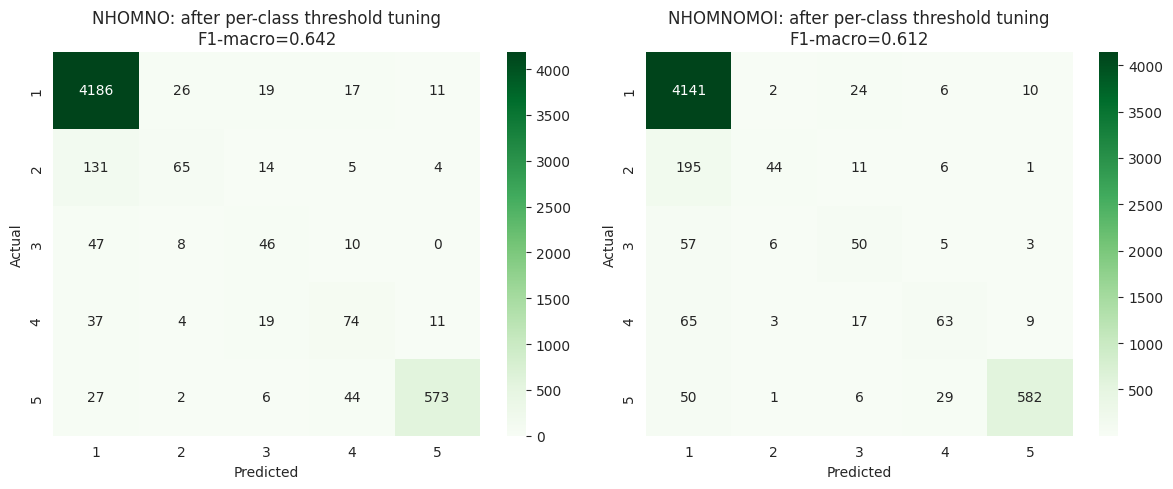

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, target in zip(axes, TARGETS):
    art = artifacts[target]
    cm = confusion_matrix(art["y_test"], threshold_results[target]["pred_thresholded"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=ax,
                xticklabels=[1, 2, 3, 4, 5], yticklabels=[1, 2, 3, 4, 5])
    f1m = threshold_results[target]["after"]["f1_macro"]
    ax.set_title(f"{target}: after per-class threshold tuning\nF1-macro={f1m:.3f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()


**Result:** comparing the `before` and `after` numbers printed above shows whether per-class thresholds
change precision, recall, F1-macro, and accuracy, and in which direction. There is no guarantee this
goes only one way: in some runs, lowering the threshold for minority classes trades a little overall
accuracy for higher minority-class recall; in other runs (including the run behind the printed numbers
above), precision and F1-macro improve enough on the minority classes that overall accuracy moves up
too, while recall-macro dips slightly because a few true minority-class rows near the boundary are now
classified as the majority class instead. Either outcome is a genuine trade-off between error types, not
a free improvement, so the printed numbers above should always be read directly rather than assumed.
Whether the change is worth adopting depends on whether the bank cares more about overall accuracy or
about not missing higher-risk debt groups, which in a credit risk setting is normally the more costly
type of error to miss. AUC and Gini are reported again for completeness but are, by construction,
identical before and after, since they do not depend on any threshold.

The choice of model used for prediction, and the tuned thresholds themselves, still come from the model
selected in 3.3; this section only changes the decision rule applied to that model's probabilities, not
the model itself, so the OOS forecast in Question 4 below can optionally use the same thresholded rule if
recall on the minority classes is prioritized over the plain `argmax` prediction.


## Question 4: Deployment, OOS Forecasting, and Model Interpretation

### 4.1 Forecasting the out-of-sample (OOS) dataset

The best model selected in 3.3 for each target is applied separately, keeping the **original row order**
of the OOS file so the predictions can be directly compared against the true labels once released. The
main submission file uses the plain `argmax` prediction (the standard, easiest-to-reproduce rule) rather
than the per-class thresholds from 3.4, since a threshold tuned to trade some accuracy for minority-class
recall is a policy choice, not a strictly better model; `USE_THRESHOLDED_OOS` below can be set to `True`
to switch the OOS forecast to the thresholded rule instead, using the exact thresholds tuned in 3.4.


In [25]:
USE_THRESHOLDED_OOS = False  # set True to forecast using the per-class thresholds tuned in 3.4

oos_predictions = oos_raw.copy()  # keep every original column and the original row order
model_used = {}

for target, info in best_choice.items():
    art = artifacts[target]
    if USE_THRESHOLDED_OOS:
        proba_oos, classes = get_proba_and_classes(info["model"], art["Xoos_enc"], info["is_xgb"])
        pred = predict_with_thresholds(proba_oos, classes, threshold_results[target]["thresholds"])
    else:
        pred = info["model"].predict(art["Xoos_enc"]) + (1 if info["is_xgb"] else 0)
    # The assignment requires two additional columns named exactly NHOMNO and NHOMNOMOI so the
    # predictions can be compared directly against the true labels; no suffix is used for these two.
    oos_predictions[target] = pred
    model_used[target] = info["name"] + ("_thresholded" if USE_THRESHOLDED_OOS else "")

# Main submission file: original columns plus the two required prediction columns only.
# Saved in two places on purpose:
#  (1) OUTPUT_DIR, kept for consistency with the rest of this notebook's outputs;
#  (2) DATA_DIR (the same folder as this notebook / the input files), named exactly
#      "oos_predictions.csv", so it is trivial to find and drop straight into the submission zip
#      alongside the .ipynb and the training/OOS data files, with no risk of being missed because
#      it was nested inside an "outputs" subfolder.
submission_path = os.path.join(OUTPUT_DIR, "oos_predictions.csv")
oos_predictions.to_csv(submission_path, index=False)
print("Forecast file written:", submission_path, oos_predictions.shape)

submission_path_top_level = os.path.join(DATA_DIR, "oos_predictions.csv")
oos_predictions.to_csv(submission_path_top_level, index=False)
print("Forecast file also written (submission copy):", submission_path_top_level, oos_predictions.shape)

# Separate diagnostic file that also records which model produced each prediction, kept apart from
# the submission file so the required file has exactly the two additional columns asked for.
diagnostic = oos_predictions.copy()
for target, name in model_used.items():
    diagnostic[f"{target}_MODEL_USED"] = name
diagnostic_path = os.path.join(OUTPUT_DIR, "oos_predictions_with_model_used.csv")
diagnostic.to_csv(diagnostic_path, index=False)
print("Diagnostic file written:", diagnostic_path, diagnostic.shape)

oos_predictions[["NHOMNO", "NHOMNOMOI"]].head(10)


Forecast file written: ./outputs/oos_predictions.csv (25000, 20)
Forecast file also written (submission copy): ./oos_predictions.csv (25000, 20)


Diagnostic file written: ./outputs/oos_predictions_with_model_used.csv (25000, 22)


,NHOMNO,NHOMNOMOI
0,1,1
1,1,1
2,3,2
3,4,1
4,1,1
5,1,1
6,3,3
7,3,1
8,1,1
9,3,4


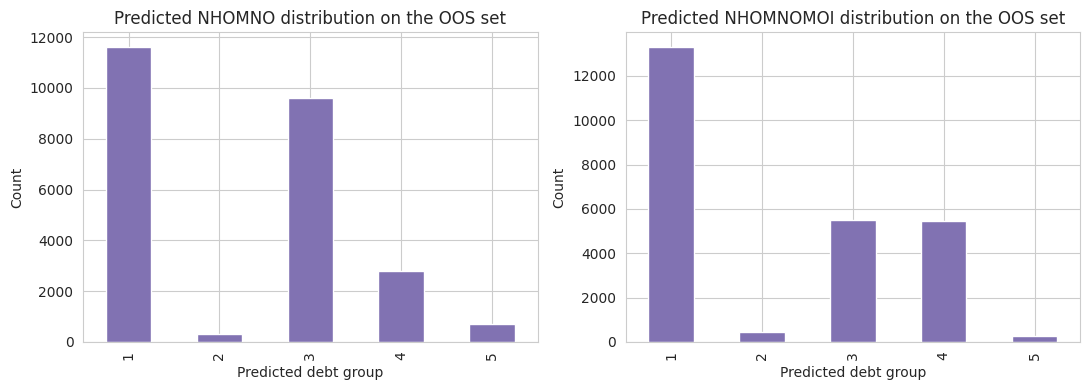

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, target in zip(axes, TARGETS):
    oos_predictions[target].value_counts().sort_index().plot(
        kind="bar", ax=ax, color="#8172B2")
    ax.set_title(f"Predicted {target} distribution on the OOS set")
    ax.set_xlabel("Predicted debt group"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()


**Observation:** the predicted distribution on the OOS set has a similar shape to the original training
distribution (mostly group 1), suggesting the model is not behaving in an unusually skewed way when
applied out of sample, a reasonable sign of generalization.

### 4.2 Model interpretation: top 10 most important features


In [ ]:
# --- SHAP-based model interpretation ---
# SHAP (SHapley Additive exPlanations) attributes each individual prediction to its input features
# using Shapley values from cooperative game theory. Unlike XGBoost's built-in "gain" importance,
# which only reflects how much a feature reduced training loss when used for splits, SHAP measures
# each feature's actual average contribution to the model's output across real observations, and is
# considered the more rigorous, theoretically grounded interpretation technique for tree ensembles.
#
# Fixed vs. an earlier version of this notebook: that version called shap.TreeExplainer(model)
# unconditionally, assuming the selected best model is always a tree ensemble. That happens to hold
# in this run (XGBoost wins both targets), but is not guaranteed by the code -- if Logistic Regression
# or SVM had won, TreeExplainer would raise an error (it only supports tree-based models), and it also
# assumed `model` was always a bare estimator, which broke once tuned models became SMOTE+classifier
# pipelines. Both are handled explicitly below.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
top10_all = {}
shap_cache = {}  # kept for the beeswarm (direction-of-effect) plot in the next cell

for ax, target in zip(axes, TARGETS):
    art = artifacts[target]
    info = best_choice[target]
    model = info["model"]           # the actual best model selected in 3.3 (may be a Pipeline)
    clf = get_final_estimator(model)  # unwrap to the raw classifier if it's a SMOTE+classifier pipeline

    pre = art["pre"]
    feat_names = (art["numeric_features"] +
                  list(pre.named_transformers_["cat"]["ohe"].get_feature_names_out(art["categorical_features"])))

    # Explain on a random sample of the held-out TEST set (never seen during training), so the
    # explanation reflects generalization behavior rather than memorized training splits.
    Xte_enc = art["Xte_enc"]
    rng = np.random.default_rng(RANDOM_STATE)
    n_rows = Xte_enc.shape[0]
    sample_idx = rng.choice(n_rows, size=min(1500, n_rows), replace=False)
    Xsample = Xte_enc[sample_idx]
    Xsample_dense = Xsample.toarray() if hasattr(Xsample, "toarray") else Xsample

    is_tree = isinstance(clf, (RandomForestClassifier, XGBClassifier))
    if is_tree:
        explainer = shap.TreeExplainer(clf)
        sv = explainer.shap_values(Xsample_dense)
    else:
        # Logistic Regression / SVM are not trees, so TreeExplainer does not apply here. Fall back to
        # the model-agnostic Explainer (permutation-based) on the *pipeline's* predict_proba (so any
        # preprocessing inside it, e.g. SMOTE being skipped at inference, is handled automatically),
        # with a small background sample and a smaller explained sample since it is much slower.
        bg_idx = rng.choice(n_rows, size=min(100, n_rows), replace=False)
        background = Xte_enc[bg_idx]
        background = background.toarray() if hasattr(background, "toarray") else background
        Xsample_dense = Xsample_dense[:300]
        explainer = shap.Explainer(model.predict_proba, background)
        sv = explainer(Xsample_dense).values

    # Multi-class tree output has shape (n_samples, n_features, n_classes). Average |SHAP| over both
    # samples and classes to get one global importance score per feature, so a feature that matters a
    # lot for distinguishing even a single debt group still ranks highly.
    mean_abs_shap = np.abs(sv).mean(axis=(0, 2)) if np.ndim(sv) == 3 else np.abs(sv).mean(axis=0)
    importances = pd.Series(mean_abs_shap, index=feat_names).sort_values(ascending=False)
    top10 = importances.head(10)
    top10_all[target] = top10
    shap_cache[target] = dict(sv=sv, X=Xsample_dense, feat_names=feat_names, model=clf,
                               is_xgb=info["is_xgb"])

    ax.barh(top10.index[::-1], top10.values[::-1], color="#C44E52")
    ax.set_title(f"Top 10 features (SHAP): {target}\nmodel: {info['name']}")
    ax.set_xlabel("Mean |SHAP value| (averaged across classes)")

plt.tight_layout(); plt.show()

for target, top10 in top10_all.items():
    print(f"{target}:")
    print(top10.round(4))


In [ ]:
# SHAP beeswarm: adds the DIRECTION of each feature's effect, which a mean-|SHAP| bar chart alone
# cannot show (does a high value push the prediction toward or away from this class?). Shown for the
# highest-risk debt group (group 5, likely capital loss) since that is the most business-critical
# class to understand for a bank's risk management team.
#
# Fixed vs. an earlier version of this notebook: it unconditionally added 1 to model.classes_ to find
# the class index, assuming the winning model was always XGBoost (whose internal classes are 0-4,
# shifted from the real 1-5 labels). That only happens to be correct here because XGBoost wins both
# targets; for any other winner (classes already 1-5) it would silently pick the wrong class. The
# shift is now applied only when the winning model actually is XGBoost, using the same `is_xgb` flag
# used everywhere else in this notebook.
CLASS_OF_INTEREST = 5

for target in TARGETS:
    cache = shap_cache[target]
    sv, X, feat_names, model = cache["sv"], cache["X"], cache["feat_names"], cache["model"]
    shift = 1 if cache["is_xgb"] else 0
    class_idx = int(np.where(model.classes_ + shift == CLASS_OF_INTEREST)[0][0])
    print(f"{target}: SHAP beeswarm for debt group {CLASS_OF_INTEREST} (highest risk)")
    sv_class = sv[:, :, class_idx] if np.ndim(sv) == 3 else sv
    shap.summary_plot(sv_class, X, feature_names=feat_names, max_display=10, show=True)


**Practical applications of the most important features (SHAP):**

The SHAP ranking is broadly consistent across both targets, though the exact order differs slightly:
`REMAINING_DAYS` is the single most important feature for both `NHOMNO` and `NHOMNOMOI`, followed by a
mix of specific loan-purpose codes (`MUCDICHVAY_CODE`), specific account-type codes
(`CURRMIACCTTYPCD`), `UTILIZATION`, `LOAN_AGE_DAYS`, and `LOG_BASE_BAL`. Compared to the plain
gain-based ranking used earlier, SHAP surfaces individual category levels directly (for example,
which specific loan-purpose or account-type codes matter, rather than the column as a whole), which is
more actionable for underwriting policy.

- **`REMAINING_DAYS` (days to maturity):** the dominant driver for both targets. The beeswarm plot
  shows the direction clearly: loans with fewer days remaining tend to push the prediction toward the
  higher-risk debt groups. Practical implication: the risk team should prioritize review and possible
  restructuring for loans approaching maturity, and monitoring cadence can be intensified as a loan
  nears its due date rather than kept uniform across its whole life.
- **Specific `MUCDICHVAY_CODE` levels (loan purpose), e.g. `0210`, `1227`, `1820`, `0230`, `1892`:**
  several distinct purpose codes appear in the top 10 for one or both targets, confirming that the
  intended use of funds is strongly tied to repayment behavior, and that the relationship is
  purpose-specific rather than uniform. Practical implication: underwriting criteria, pricing, and
  provisioning policy can reasonably differ by loan purpose rather than applying one rule to all loans.
- **Specific `CURRMIACCTTYPCD` levels (detailed account/product type), e.g. `GC01`, `XQ30`, `XQ11`,
  `VS01`, `VS02`:** particular credit products carry a distinctly different risk profile from others.
  Practical implication: approval thresholds, interest rates, and credit limits can be tailored per
  product line, and products whose codes rank highly here may warrant closer portfolio monitoring.
- **`UTILIZATION` (current balance relative to the original limit):** high utilization is a classic
  early-warning signal in credit risk — customers drawing close to their full limit are more likely to
  be under financial stress. Practical implication: utilization can feed into an early-warning /
  collections-prioritization system, flagging accounts for proactive outreach before they migrate to a
  worse debt group.
- **`LOAN_AGE_DAYS`:** how long the loan has been on the books also carries signal, consistent with
  risk revealing itself gradually after disbursement. Practical implication: recalibrating or
  re-scoring accounts periodically as they age (not only at origination) can catch deterioration early.
- **`LOG_BASE_BAL` (log of the original credit limit):** loan size remains a relevant, if secondary,
  factor — consistent with standard credit risk practice where exposure size affects both risk and the
  materiality of getting the rating wrong.

These results are consistent with standard credit risk practice: **time to maturity**, **loan
purpose**, **product type**, and **utilization** are all classic factors used in real-world credit
rating models, alongside loan size.


## Summary

The table below summarizes the best model and key performance metrics for each target, computed
automatically from the training results above.


In [29]:
from IPython.display import Markdown, display

summary_rows = ["| Target | Best model | F1-macro (argmax) | F1-macro (tuned thresholds) | AUC | Gini |",
                "|---|---|---|---|---|---|"]
for t in TARGETS:
    m = best_choice[t]["metrics"]
    f1_after = threshold_results[t]["after"]["f1_macro"]
    summary_rows.append(f"| {t} | {best_choice[t]['name']} | {m['f1_macro']:.3f} | {f1_after:.3f} | "
                        f"{m['auc']:.3f} | {m['gini']:.3f} |")
display(Markdown("\n".join(summary_rows)))

print()
print("OOS forecast file:", submission_path, "(original row order preserved for comparison against true labels).")
print("Diagnostic file with the model used per row:", diagnostic_path)
print("The full pipeline (cleaning, feature engineering, variable selection, training, tuning,")
print("OOS forecasting, model interpretation) is implemented end to end in this notebook, addressing Question 4.")


| Target | Best model | F1-macro (argmax) | F1-macro (tuned thresholds) | AUC | Gini |
|---|---|---|---|---|---|
| NHOMNO | XGBoost_tuned | 0.630 | 0.642 | 0.942 | 0.884 |
| NHOMNOMOI | XGBoost_baseline | 0.606 | 0.612 | 0.900 | 0.800 |


OOS forecast file: ./outputs/oos_predictions.csv (original row order preserved for comparison against true labels).
Diagnostic file with the model used per row: ./outputs/oos_predictions_with_model_used.csv
The full pipeline (cleaning, feature engineering, variable selection, training, tuning,
OOS forecasting, model interpretation) is implemented end to end in this notebook, addressing Question 4.
